In [1]:
%reset -f
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def gen_txt2df(file_path):

    data = []
    current_block = ""

    with open(file_path, "r") as f:
        for line in f:
            # If a new generation starts, save the previous block
            if "Gen " in line and current_block:
                data.append(current_block)
                current_block = line.strip()
            else:
                current_block += " " + line.strip()

    # Add last block
    if current_block:
        data.append(current_block)


    # Now parse each full generation block
    rows = []

    for block in data:
        row = {}

        # Generation
        gen_match = re.search(r"Gen (\d+)", block)
        if gen_match:
            row["gen"] = int(gen_match.group(1))

        # Fitness
        fit_match = re.search(r"Best Fitness = ([\d\.\-eE]+)", block)
        if fit_match:
            row["fitness"] = float(fit_match.group(1))

        # Range
        range_match = re.search(r"Range: ([\d\.]+)", block)
        if range_match:
            row["range"] = float(range_match.group(1))

        # Mass
        mass_match = re.search(r"Mass: ([\d\.]+)", block)
        if mass_match:
            row["mass"] = float(mass_match.group(1))

        # All "Name: value" pairs
        matches = re.findall(r"([A-Za-z\s]+): ([\-\d\.eE]+)", block)
        for name, val in matches:
            key = name.strip().lower().replace(" ", "_")
            row[key] = float(val)

        rows.append(row)

    df = pd.DataFrame(rows)

    return df



In [2]:
run5_filepath = r"C:\Users\mayar\Documents\Ryerson\Grad Classes\AE8139 MDO\MDO_opt\run_5_mass.txt"
run6_filepath = r"C:\Users\mayar\Documents\Ryerson\Grad Classes\AE8139 MDO\MDO_opt\run_6_solperpop.txt"
run7_filepath = r"C:\Users\mayar\Documents\Ryerson\Grad Classes\AE8139 MDO\MDO_opt\run_7_initpop.txt"
run8_filepath = r"C:\Users\mayar\Documents\Ryerson\Grad Classes\AE8139 MDO\MDO_opt\run_8_initpop.txt"
run9_filepath = r"C:\Users\mayar\Documents\Ryerson\Grad Classes\AE8139 MDO\MDO_opt\run_9_parmate.txt"

df_run5 = gen_txt2df(run5_filepath)
df_run6 = gen_txt2df(run6_filepath)
df_run7 = gen_txt2df(run7_filepath)
df_run8 = gen_txt2df(run8_filepath)
df_run9 = gen_txt2df(run9_filepath)

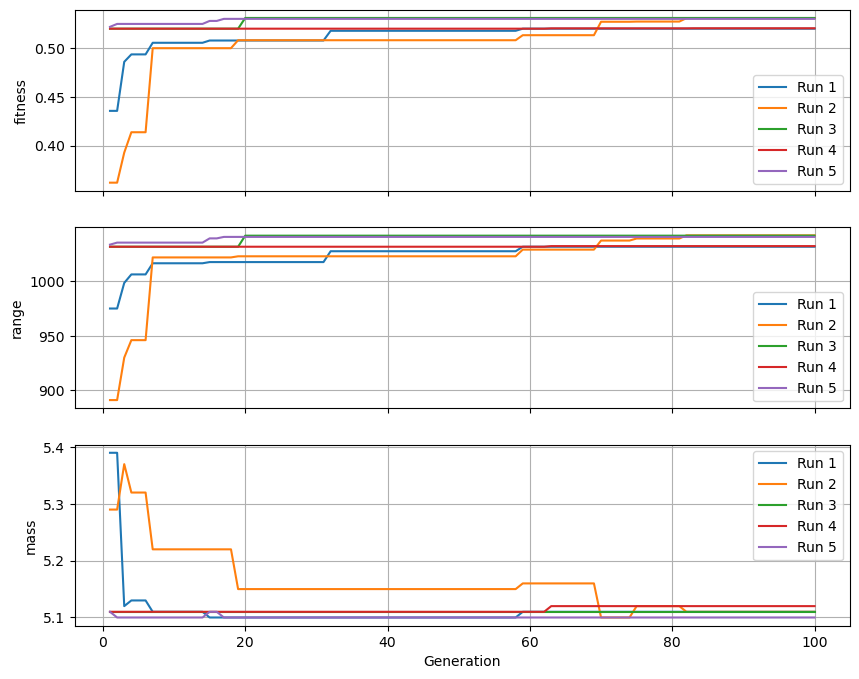

In [3]:
vars_to_plot = ["fitness", "range", "mass"]

fig, axs = plt.subplots(len(vars_to_plot), 1, sharex=True, figsize=(10,8))


for i, var in enumerate(vars_to_plot):
    axs[i].plot(df_run5["gen"], df_run5[var], label="Run 1")
    axs[i].plot(df_run6["gen"], df_run6[var], label="Run 2")
    axs[i].plot(df_run7["gen"], df_run7[var], label="Run 3")
    axs[i].plot(df_run8["gen"], df_run8[var], label="Run 4")
    axs[i].plot(df_run9["gen"], df_run9[var], label="Run 5")
    axs[i].set_ylabel(var)
    axs[i].grid()
    axs[i].legend()

axs[-1].set_xlabel("Generation")

plt.show()

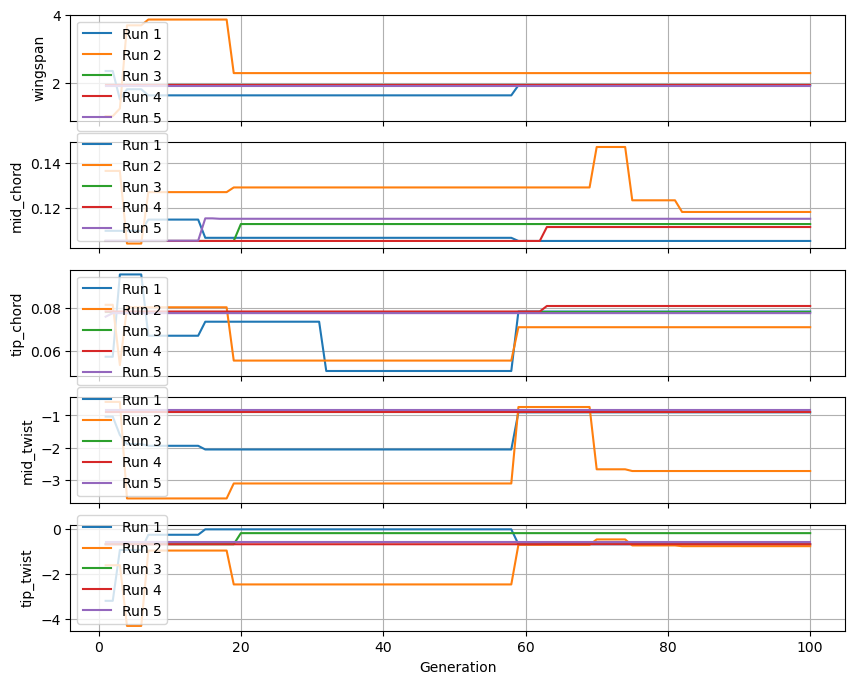

In [4]:
vars_to_plot = ["wingspan", "mid_chord", "tip_chord", "mid_twist", "tip_twist"]

fig, axs = plt.subplots(len(vars_to_plot), 1, sharex=True, figsize=(10,8))


for i, var in enumerate(vars_to_plot):
    axs[i].plot(df_run5["gen"], df_run5[var], label="Run 1")
    axs[i].plot(df_run6["gen"], df_run6[var], label="Run 2")
    axs[i].plot(df_run7["gen"], df_run7[var], label="Run 3")
    axs[i].plot(df_run8["gen"], df_run8[var], label="Run 4")
    axs[i].plot(df_run9["gen"], df_run9[var], label="Run 5")
    axs[i].set_ylabel(var)
    axs[i].grid()
    axs[i].legend()

axs[-1].set_xlabel("Generation")

plt.show()

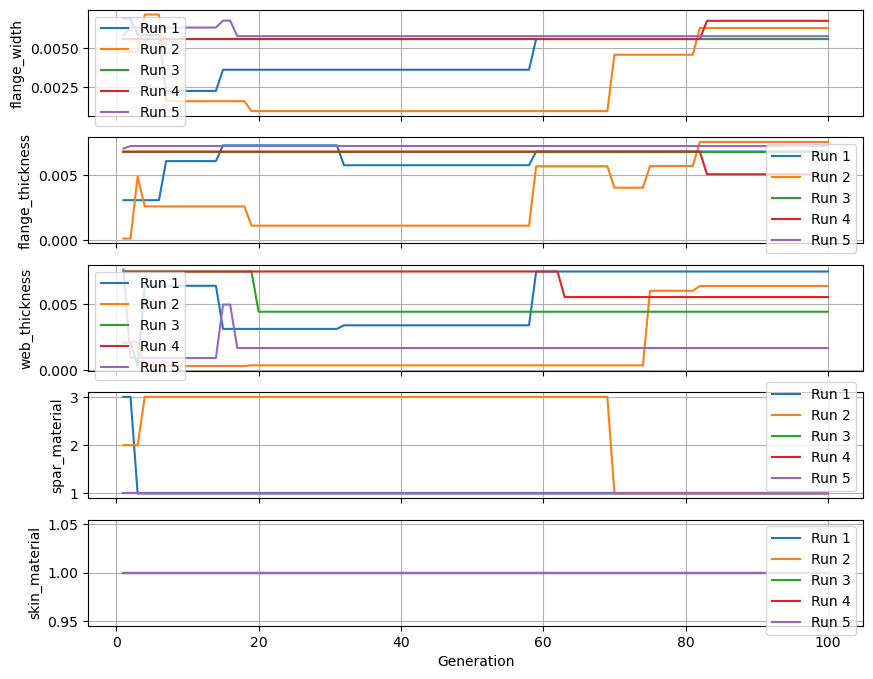

In [5]:
vars_to_plot = ["flange_width", "flange_thickness", "web_thickness", "spar_material", "skin_material"]

fig, axs = plt.subplots(len(vars_to_plot), 1, sharex=True, figsize=(10,8))


for i, var in enumerate(vars_to_plot):
    axs[i].plot(df_run5["gen"], df_run5[var], label="Run 1")
    axs[i].plot(df_run6["gen"], df_run6[var], label="Run 2")
    axs[i].plot(df_run7["gen"], df_run7[var], label="Run 3")
    axs[i].plot(df_run8["gen"], df_run8[var], label="Run 4")
    axs[i].plot(df_run9["gen"], df_run9[var], label="Run 5")
    axs[i].set_ylabel(var)
    axs[i].grid()
    axs[i].legend()

axs[-1].set_xlabel("Generation")

plt.show()

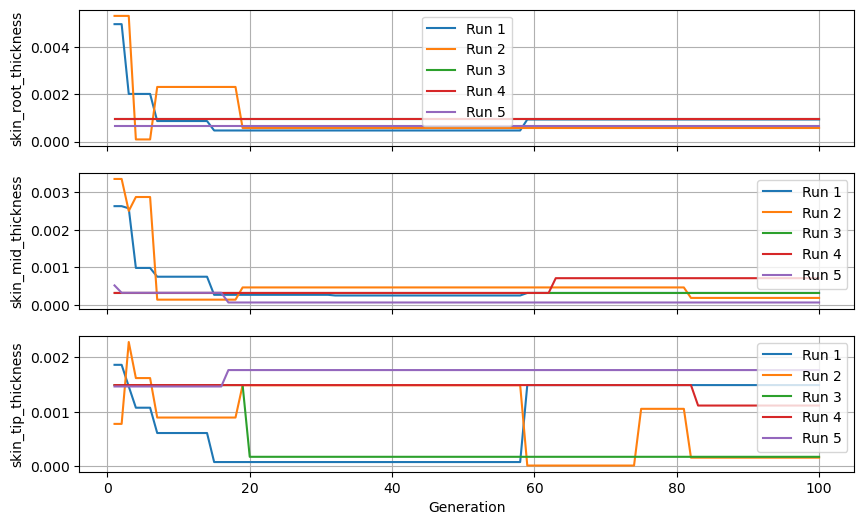

In [6]:
vars_to_plot = ["skin_root_thickness", "skin_mid_thickness","skin_tip_thickness"]

fig, axs = plt.subplots(len(vars_to_plot), 1, sharex=True, figsize=(10,6))


for i, var in enumerate(vars_to_plot):
    axs[i].plot(df_run5["gen"], df_run5[var], label="Run 1")
    axs[i].plot(df_run6["gen"], df_run6[var], label="Run 2")
    axs[i].plot(df_run7["gen"], df_run7[var], label="Run 3")
    axs[i].plot(df_run8["gen"], df_run8[var], label="Run 4")
    axs[i].plot(df_run9["gen"], df_run9[var], label="Run 5")
    axs[i].set_ylabel(var)
    axs[i].grid()
    axs[i].legend()

axs[-1].set_xlabel("Generation")

plt.show()

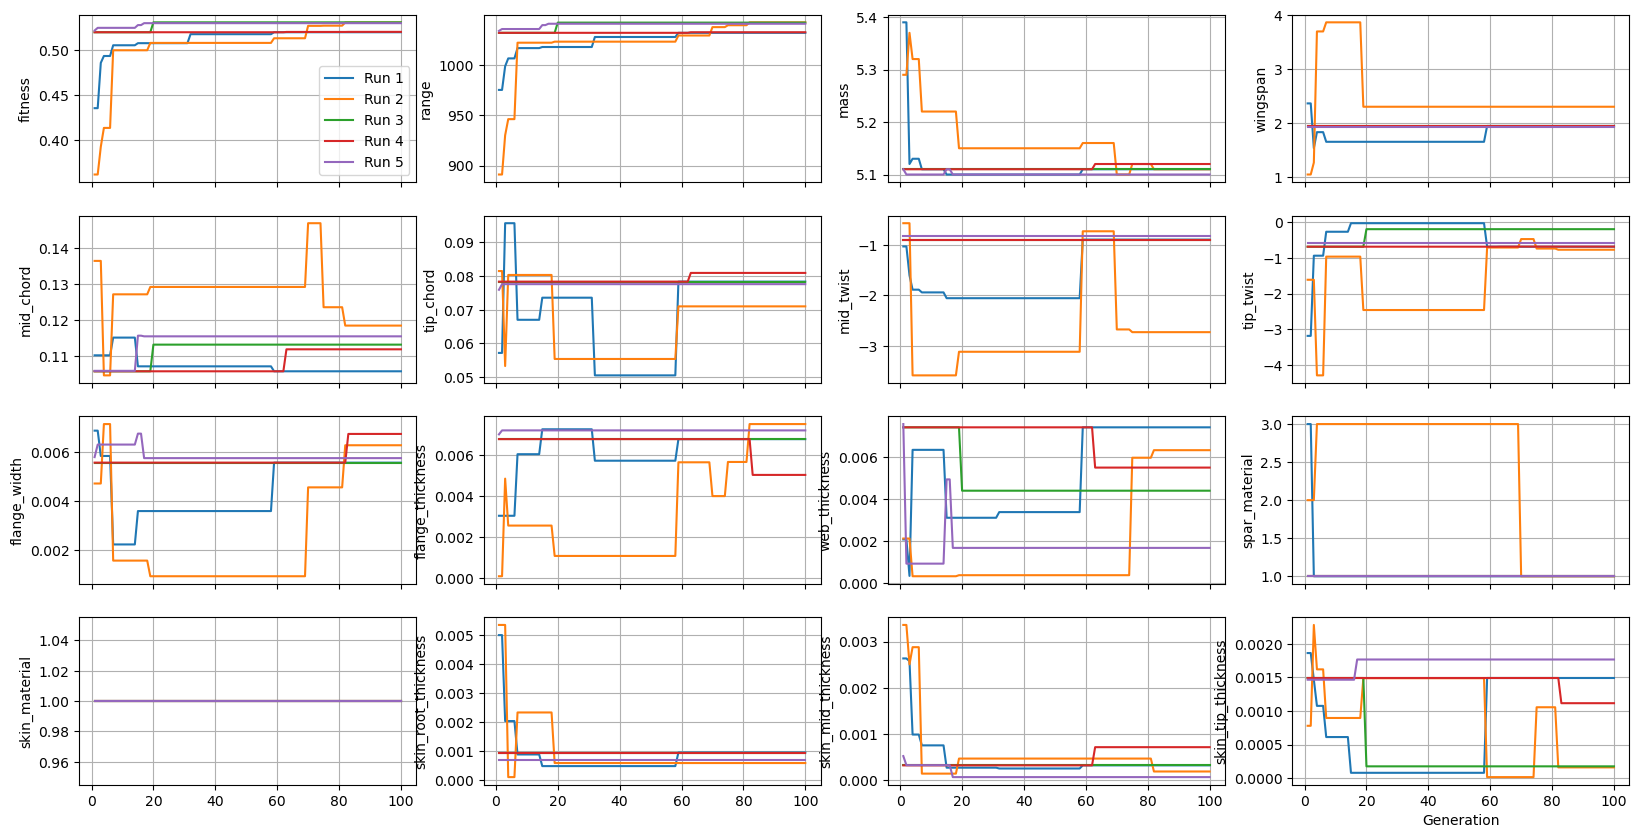

In [7]:
vars_to_plot = ["fitness", "range", "mass",
                "wingspan", "mid_chord", "tip_chord", "mid_twist", "tip_twist",
                "flange_width", "flange_thickness", "web_thickness", "spar_material", "skin_material",
                "skin_root_thickness", "skin_mid_thickness","skin_tip_thickness"]

fig, axs = plt.subplots(4, 4, sharex=True, figsize=(20,10))
axs = axs.flatten()

for i, var in enumerate(vars_to_plot):
    axs[i].plot(df_run5["gen"], df_run5[var], label="Run 1")
    axs[i].plot(df_run6["gen"], df_run6[var], label="Run 2")
    axs[i].plot(df_run7["gen"], df_run7[var], label="Run 3")
    axs[i].plot(df_run8["gen"], df_run8[var], label="Run 4")
    axs[i].plot(df_run9["gen"], df_run9[var], label="Run 5")
    axs[i].set_ylabel(var)
    axs[i].grid()
    if i==0:
        axs[i].legend()

axs[-1].set_xlabel("Generation")

plt.show()

In [8]:
def spar_area(chord, t_skin, t_flange, w_flange, t_web):
    
    thickness = 0.303*chord
    h_web = thickness - (2*t_skin) - (2*t_flange)
    a_spar = (t_flange*w_flange*2) + (t_web*h_web)
    
    return a_spar

def struct_vol(wingspan, mid_chord, tip_chord, t_skin_root, t_skin_mid, t_skin_tip, t_flange, w_flange, t_web):

    half_span = wingspan/2
    y_pos = np.linspace(0,half_span,100)

    a_y_spar = np.zeros(len(y_pos))
    chord_y = np.zeros(len(y_pos))
    thickness_y = np.zeros(len(y_pos))

    for i in range(len(y_pos)):
        if (y_pos[i] < half_span/2):
            y_local = y_pos[i]/(half_span/2)
            chord_y[i] = 0.15 + (mid_chord-0.15)*y_local
            thickness_y[i] = t_skin_root + (t_skin_mid-t_skin_root)*y_local
            t_flange_y = (t_flange/0.15)*chord_y[i]
            w_flange_y = (w_flange/0.15)*chord_y[i]
            t_web_y = (t_web/0.15)*chord_y[i]
            a_y_spar[i] = spar_area(chord_y[i], thickness_y[i], t_flange_y, w_flange_y, t_web_y)
        else:
            y_local = (y_pos[i]-(half_span/2))/(half_span/2)
            chord_y[i] = mid_chord + (tip_chord-mid_chord)*y_local
            thickness_y[i] = t_skin_mid + (t_skin_tip-t_skin_mid)*y_local
            t_flange_y = (t_flange/0.15)*chord_y[i]
            w_flange_y = (w_flange/0.15)*chord_y[i]
            t_web_y = (t_web/0.15)*chord_y[i]
            a_y_spar[i] = spar_area(chord_y[i], thickness_y[i], t_flange_y, w_flange_y, t_web_y)

    return chord_y, thickness_y

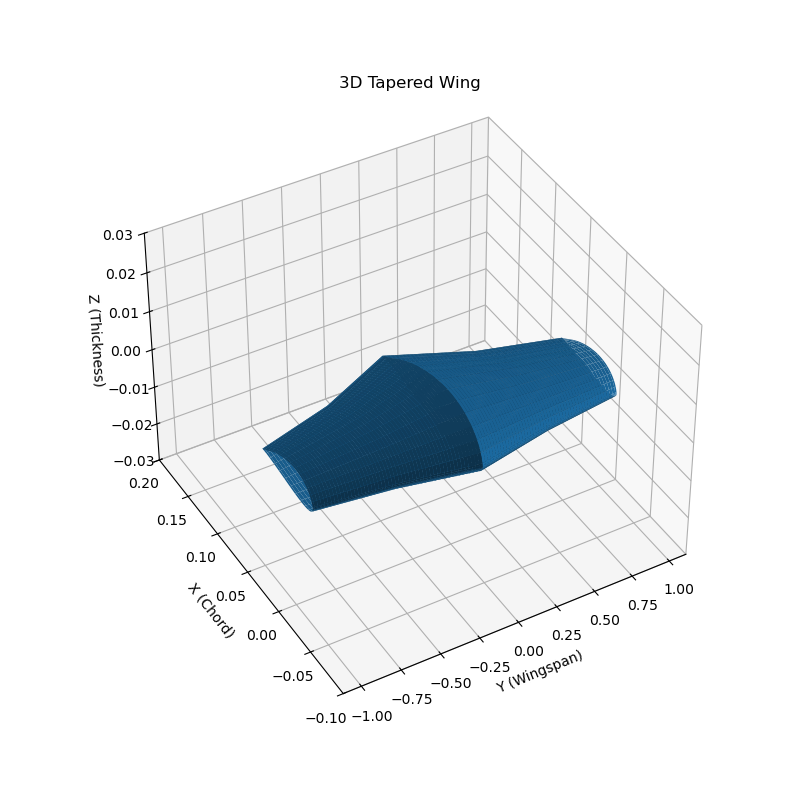

In [9]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
# from Mass import struct_vol
plt.close()

# --- 1. Get 2D Airfoil Coordinates ---
# Example: Using a simple hardcoded airfoil shape
# For real NACA airfoils, you can generate them using formulas or libraries
# as discussed in resources like the Medium tutorial.
# x and y should be 1D arrays of coordinates (e.g., from leading edge to trailing edge)

col_headers = ['x','y']
mh32_airfoil = pd.read_csv(r'C:\Users\mayar\Documents\Ryerson\Grad Classes\AE8139 MDO\MH32.dat', skiprows=1, sep=r'\s+', names=col_headers)

x_airfoil = mh32_airfoil['x']
y_airfoil = mh32_airfoil['y']

# --- 2. Define the Wing Span ---

chord = 0.15
wing_span = df_run5['wingspan'][99]
num_span_points = 100

vars_to_plot = ["fitness", "range", "mass",
                "wingspan", "mid_chord", "tip_chord", "mid_twist", "tip_twist",
                "flange_width", "flange_thickness", "web_thickness", "spar_material", "skin_material",
                "skin_root_thickness", "skin_mid_thickness","skin_tip_thickness"]

chord_y, thickness_y = struct_vol(df_run5['wingspan'][99], df_run5['mid_chord'][99], df_run5['tip_chord'][99], 
                                  df_run5['skin_root_thickness'][99], df_run5['skin_mid_thickness'][99], df_run5['skin_tip_thickness'][99], 
                                  df_run5['flange_thickness'][99], df_run5['flange_width'][99], df_run5['web_thickness'][99])

# --- Create span stations ---
z_span = np.linspace(0, wing_span/2, len(chord_y))

# Convert airfoil to numpy
x_airfoil = x_airfoil.values
x_airfoil = x_airfoil - 0.3
y_airfoil = y_airfoil.values

# Create empty surface arrays
X = np.zeros((len(z_span), len(x_airfoil)))
Y = np.zeros_like(X)
Z = np.zeros_like(X)

# --- Build wing surface ---
for j in range(len(z_span)):
    chord_local = chord_y[j]

    X[j, :] = x_airfoil * chord_local          # chordwise direction
    Y[j, :] = y_airfoil * chord_local          # thickness direction
    Z[j, :] = z_span[j]                        # spanwise direction

# --- Plot ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Z, X, Y, edgecolor='none',color='tab:blue')
ax.plot_surface(-Z, X, Y, edgecolor='none',color='tab:blue')
ax.set_xlabel('Y (Wingspan)')
ax.set_ylabel('X (Chord)')
ax.set_zlabel('Z (Thickness)')
ax.set_title('3D Tapered Wing')

ax.set_zlim([-0.03,0.03])
ax.set_ylim([-0.1,0.2])

ax.view_init(elev=40., azim=-120)

plt.show()

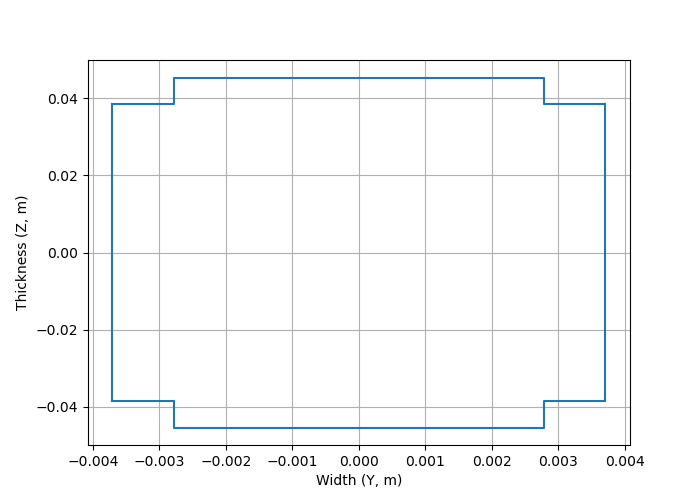

In [10]:
fig, ax1 = plt.subplots(1,1,figsize=(7,5))

t_flange = df_run5['flange_thickness'][99]
w_flange = df_run5['flange_width'][99]
t_web = df_run5['web_thickness'][99]
t_wing = 0.15*0.303

x1_spar = np.array([-t_web/2, -w_flange/2, -w_flange/2, w_flange/2, w_flange/2, t_web/2])
x2_spar = np.array([-t_web/2, -w_flange/2, -w_flange/2, w_flange/2, w_flange/2, t_web/2])
y1_spar = np.array([t_wing-t_flange, t_wing-t_flange, t_wing, t_wing, t_wing-t_flange, t_wing-t_flange])
y2_spar = np.array([-(t_wing-t_flange), -(t_wing-t_flange), -(t_wing), -(t_wing), -(t_wing-t_flange), -(t_wing-t_flange)])

# ax1.scatter(np.array([x_spar,x_spar]), np.array([y_spar,-y_spar]))
ax1.plot(x1_spar, y1_spar, color='tab:blue')
ax1.plot(x2_spar, y2_spar, color='tab:blue')
ax1.plot([-t_web/2,-t_web/2],[t_wing-t_flange,-(t_wing-t_flange)], color='tab:blue')
ax1.plot([t_web/2,t_web/2],[t_wing-t_flange,-(t_wing-t_flange)], color='tab:blue')
ax1.set_xlabel('Width (Y, m)')
ax1.set_ylabel('Thickness (Z, m)')
ax1.grid()

plt.show()

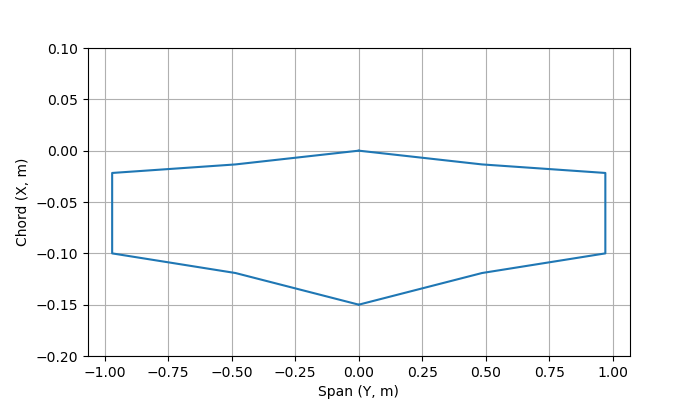

In [11]:
fig, ax1 = plt.subplots(1,1,figsize=(7,4))

wingspan = df_run5['wingspan'][99]
mid_chord = df_run5['mid_chord'][99]
tip_chord = df_run5['tip_chord'][99]
root_chord = 0.15

x1_wing = np.array([0, wingspan/4, wingspan/2, wingspan/2, wingspan/4, 0])
y1_wing = np.array([0, -((root_chord*0.303)-(mid_chord*0.303)), -((root_chord*0.303)-(tip_chord*0.303)), 
                    (-((root_chord*0.303)-(tip_chord*0.303)))-tip_chord, (-((root_chord*0.303)-(mid_chord*0.303)))-mid_chord, -0.15])

ax1.plot(x1_wing, y1_wing, color='tab:blue')
ax1.plot(-x1_wing, y1_wing, color='tab:blue')
ax1.set_xlabel('Span (Y, m)')
ax1.set_ylabel('Chord (X, m)')
ax1.set_ylim([-0.2,0.1])
ax1.grid()

plt.show()

In [12]:
def rotate_about_point(x, y, theta, x0=0.0, y0=0.0):
    """
    Rotate (x, y) about (x0, y0) by angle theta (radians)
    """
    x_shift = x - x0
    y_shift = y - y0

    x_rot = x_shift*np.cos(theta) - y_shift*np.sin(theta)
    y_rot = x_shift*np.sin(theta) + y_shift*np.cos(theta)

    return x_rot + x0, y_rot + y0

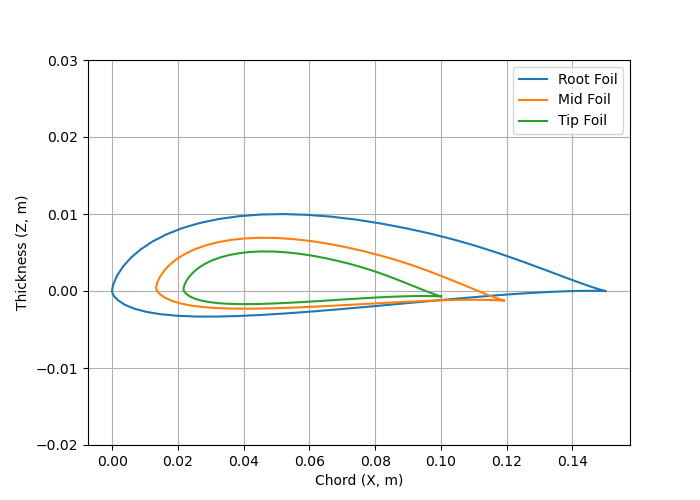

In [15]:
fig, ax1 = plt.subplots(1,1,figsize=(7,5))

t_root_skin = df_run5['skin_root_thickness'][99]
t_mid_skin = df_run5['skin_mid_thickness'][99]
t_tip_skin = df_run5['skin_tip_thickness'][99]
mid_twist = df_run5['mid_twist'][99]
tip_twist = df_run5['tip_twist'][99]

x_airfoil = mh32_airfoil['x']
y_airfoil = mh32_airfoil['y']

x_mid, y_mid = rotate_about_point((x_airfoil*mid_chord),y_airfoil*mid_chord,np.deg2rad(mid_twist),0.25*mid_chord, 0)
x_tip, y_tip = rotate_about_point((x_airfoil*tip_chord),y_airfoil*tip_chord,np.deg2rad(tip_twist),0.25*tip_chord, 0)

ax1.plot(x_airfoil*root_chord, y_airfoil*root_chord, color='tab:blue', label='Root Foil')
# ax1.plot(x_airfoil*(root_chord-(t_root_skin/2)), y_airfoil*(root_chord-(t_root_skin/2)), color='tab:blue', label='Root Foil')
ax1.plot(x_mid+((root_chord*0.303)-(mid_chord*0.303)), y_mid, color='tab:orange', label='Mid Foil')
ax1.plot(x_tip+((root_chord*0.303)-(tip_chord*0.303)), y_tip, color='tab:green', label='Tip Foil')
# ax1.plot(-x1_wing, y1_wing, color='tab:blue')
ax1.set_xlabel('Chord (X, m)')
ax1.set_ylabel('Thickness (Z, m)')
ax1.set_ylim([-0.02,0.03])
ax1.legend()
ax1.grid()